In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

Matplotlib is building the font cache; this may take a moment.


In [2]:
import sys

print(sys.executable)
print(sys.version)

/Users/adarshpatkar/fitsense-ai/.venv/bin/python
3.10.8 (v3.10.8:aaaf517424, Oct 11 2022, 10:14:40) [Clang 13.0.0 (clang-1300.0.29.30)]


In [3]:
import pandas as pd

df = pd.read_csv('../data/raw/calories.csv')

print(df.shape)
df.head()

(15000, 9)


,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [4]:
df.columns

Index(['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'Calories'],
      dtype='object')

In [5]:
df.info()
df.isnull().sum()
df.describe()
df['Calories'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


count    15000.000000
mean        89.539533
std         62.456978
min          1.000000
25%         35.000000
50%         79.000000
75%        138.000000
max        314.000000
Name: Calories, dtype: float64

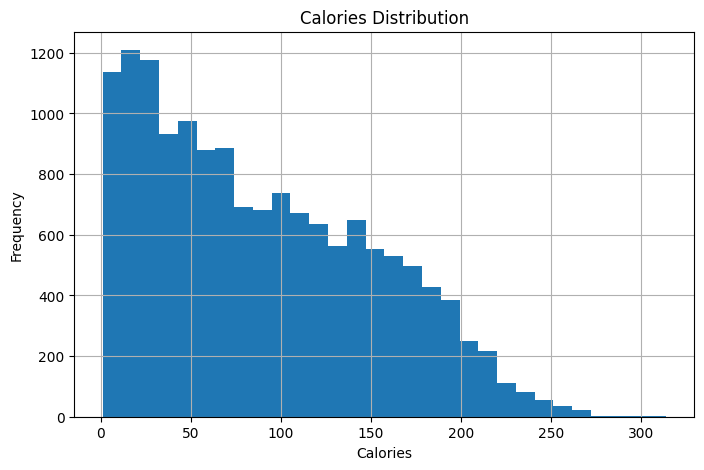

In [ ]:
# We are doing EDA- understanding data, checking quality and understanding target distrubution

df['Calories'].hist(bins=30, figsize=(8,5))
plt.xlabel('Calories')
plt.ylabel('Frequency')
plt.title('Calories Distribution')
plt.show()

In [7]:
df['Gender'].value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

In [8]:
df['Gender'].value_counts(normalize=True) * 100

Gender
female    50.353333
male      49.646667
Name: proportion, dtype: float64

In [9]:
def classify_intensity(calories):
    if calories <= 35:
        return "Low"
    elif calories <= 138:
        return "Medium"
    else:
        return "High"

In [ ]:
# defined a new col based on calorie expenditure using quaratile based thresold derived from data-distrubution
df['Workout_Intensity'] = df['Calories'].apply(classify_intensity)

In [11]:
df['Workout_Intensity'].value_counts()

Workout_Intensity
Medium    7503
Low       3798
High      3699
Name: count, dtype: int64

In [12]:
df['Workout_Intensity'].value_counts(normalize=True) * 100

Workout_Intensity
Medium    50.02
Low       25.32
High      24.66
Name: proportion, dtype: float64

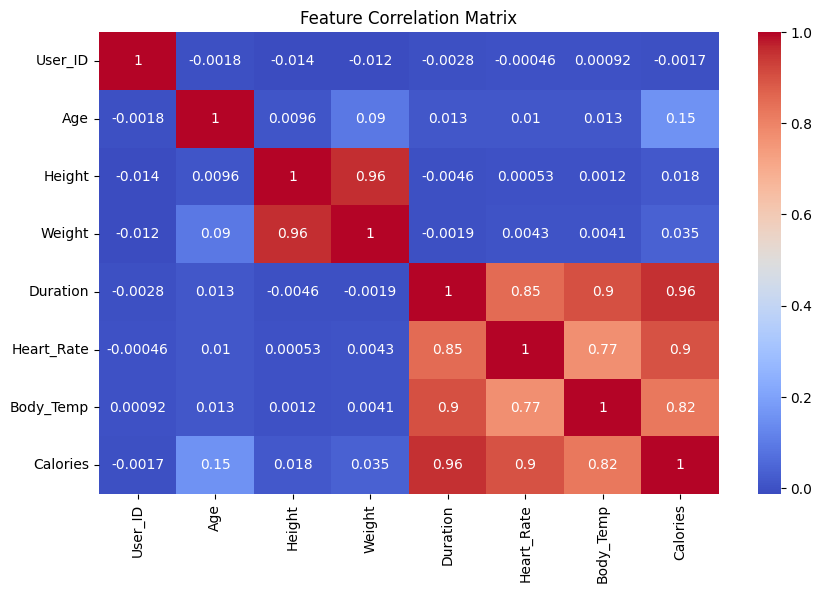

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")
plt.show()

In [ ]:
# what this heat map show is duration and heart rate has a strongest correlation with calories burn
# how to read heat map is:
# +1-- strongest correlation, 0-- no relation, -1-- negative relation ship
# also here we can see user id has a relationship of -0.0017 with calories that means it has no relationship that means it must be removed before trainig model

In [16]:
df.nunique()

User_ID              15000
Gender                   2
Age                     60
Height                  90
Weight                  91
Duration                30
Heart_Rate              59
Body_Temp               45
Calories               277
Workout_Intensity        3
dtype: int64

In [17]:
df.to_csv('../data/processed/processed_fitness.csv', index=False)